# 第8周｜生存模型评价与校准

学习目标：Harrell C、IPCW C、时间依赖AUC、Brier、分组KM校准。

__数据：默认使用官方 PRIME-CVD 5 万人数据__（`python run.py download` 下载，来源与 MD5 核验记录在 `data/raw/manifest.json`）。把 `MODE` 改成 `"demo"` 可以切换到离线演示数据，但演示数据是另外生成的，**不是 PRIME-CVD**，结果不能当作官方结果。

本周验收：提交评价表、校准图及其解释；注明删失假设。

In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
from IPython.display import display

# 从项目根目录、notebooks目录或其他项目内目录启动均可。
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "run.py").exists()), None)
if ROOT is None:
    raise RuntimeError("请在解压后的项目目录中启动 Jupyter。")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from primecvd.common import load_config, provenance_label
from primecvd.pipeline import prepare
from primecvd.splitting import select_split

MODE = "official"  # 官方数据；离线练习或跑测试时可改为 "demo"（演示数据不是 PRIME-CVD）
cfg = load_config(ROOT / "configs" / f"{MODE}.json")
cfg["output_dir"] = f"outputs/notebooks_{MODE}"
print(provenance_label(cfg))
df, splits = prepare(cfg)
train = select_split(df, splits, "train")
valid = select_split(df, splits, "valid")
# 不创建test DataFrame；模型试验只使用train和valid。
print("队列、训练集、验证集：", len(df), len(train), len(valid))

# 命令行绘图模块采用无窗口后端；在Notebook中显式启用行内图像。
get_ipython().run_line_magic("matplotlib", "inline")
from primecvd import pubplot as pp   # 与精讲篇相同的顶刊作图风格（在启用行内图像之后设置）
pp.setup()

OFFICIAL SOURCE FILES / 官方下载文件
队列、训练集、验证集： 50000 35000 7500


## 排序、风险数值和误差分开看
为让本Notebook可独立运行，使用预先固定的普通Cox；核心流水线另有训练内CV选择方案。下面的验证集结果不是最终测试结果。

In [2]:
from primecvd.survival import CoxModel
from primecvd.metrics import evaluate_survival, calibration_edges, calibration_table
model = CoxModel(cfg["features"], alpha=0.0).fit(train)
h = cfg["horizon_years"]
p_valid = model.predict_risk(valid, h)
metrics = evaluate_survival(train, valid, p_valid, model.score(valid), h, cfg["min_censor_survival"])
display(pd.Series(metrics))

n                        7500.000000
observed_events           302.000000
events_by_horizon         293.000000
early_censored           4180.000000
at_risk_after_horizon    3027.000000
horizon_years               5.000000
mean_predicted_risk         0.040549
KM_risk                     0.040297
KM_risk_ci_low              0.035992
KM_risk_ci_high             0.045106
Harrell_C                   0.875205
Uno_C_to_horizon            0.873691
AUC_IPCW                    0.876690
Brier_IPCW                  0.027280
dtype: float64

Harrell C描述可比较人员对的风险排序；IPCW方法用训练集估计的删失分布加权，依赖独立删失和足够随访支持；Brier同时对风险预测误差敏感。早期删失者不被当作已知五年阴性。

,group,n,events_by_horizon,at_risk_after_horizon,mean_prediction,KM_risk,ci_low,ci_high,sparse_or_unsupported
0,1,1598,3,652,0.003139,0.001877,0.000606,0.005809,True
1,2,1496,13,602,0.007055,0.009230,0.005350,0.015904,False
2,3,1468,19,607,0.012118,0.013204,0.008434,0.020642,False
3,4,1443,29,622,0.022200,0.020934,0.014569,0.030037,False
4,5,1495,229,544,0.159682,0.157403,0.139527,0.177325,False


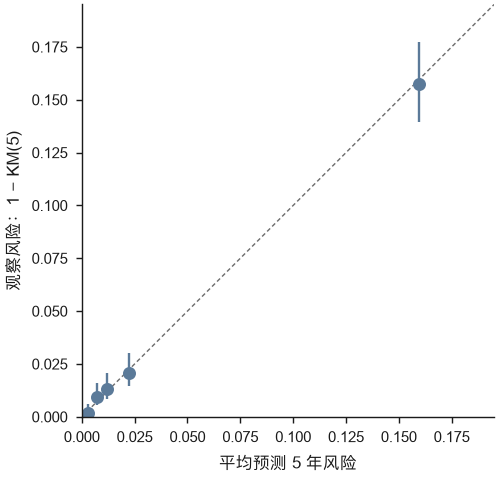

In [3]:
edges = calibration_edges(model.predict_risk(train, h), cfg["calibration_bins"])
cal = calibration_table(valid.cvd_time, valid.cvd_event, p_valid, h, edges)
display(cal)
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=pp.size(pp.SINGLE, 80))
high = float(max(cal.mean_prediction.max(), cal.KM_risk.max(), cal.ci_high.max())) * 1.1
ax.plot([0, high], [0, high], color=pp.GREY, lw=0.6, ls=(0, (3, 2)), zorder=0)     # 完美校准线
ok = cal.ci_low.notna() & cal.ci_high.notna()
ax.vlines(cal.mean_prediction[ok], cal.ci_low[ok], cal.ci_high[ok], color=pp.NEUTRAL, lw=1)
ax.plot(cal.mean_prediction, cal.KM_risk, "o", color=pp.NEUTRAL, ms=4.5)
ax.set(xlim=(0, high), ylim=(0, high), xlabel="平均预测 5 年风险", ylabel="观察风险：1 − KM(5)")
ax.set_aspect("equal")                                # 横纵轴同比例，对角线才是 45°
plt.show()

分组边界来自训练预测，不从测试集学习。样本少、事件少或时间支持不足的组会标记`sparse_or_unsupported`。分组KM校准是粗略描述，不能替代完整校准建模。

## 独立练习
构造一个“风险排序不变，但所有预测概率偏高”的例子，思考哪些指标会变化。不要把校准图中的组内KM置信区间称为模型总体性能置信区间。

---
本周复盘：请用自己的话记录一个学会的概念、一个发现的错误和一个待解决问题。

特别提醒：普通ROC不能直接处理早期删失；边际IPCW并非适合所有真实资料。